# GNN Validation Experiment — Plug-and-Play Architecture Testing

**Goal:** Verify that each GNN architecture (a) converges and (b) actually exploits the EU trade network topology, rather than just memorising node features.

## Pipeline overview
| Stage | Description |
|---|---|
| **Data** | Same cleaned CSVs as before — no imputation needed |
| **Stability setup** | `log1p / 25.0` target scaling · manual self-loops · gradient clipping |
| **Model** | `PlugAndPlayGNN`: Linear encoder → 2-layer GNN backbone → link-predictor MLP |
| **Phase 1a Stability test** | 50 epochs, fixed LR — loss must decrease, predictions must not collapse |
| **Phase 1b Topology test** | Same model trained on shuffled edge_index — real graph must beat shuffled |
| **Sweep** | `[GCNConv, GATv2Conv, SAGEConv, TransformerConv]` |


In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell A — Imports & Configuration
# ══════════════════════════════════════════════════════════════════════════════

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

try:
    from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv, TransformerConv
    HAS_PYG = True
    print("✓ PyTorch Geometric available")
except ImportError:
    HAS_PYG = False
    print("✗ PyTorch Geometric not found — run: pip install torch-geometric")

warnings.filterwarnings("ignore", category=UserWarning)

# ── Canonical configuration (must match the pipeline) ─────────────────────────
START_MONTH = "2014-01"
END_MONTH   = "2025-11"
MONTHLY_IDX = pd.date_range(START_MONTH, END_MONTH, freq="MS")

COUNTRIES = [
    "AT", "BE", "BG", "CY", "CZ", "DE", "DK", "EE", "EL",
    "ES", "FI", "FR", "HR", "HU", "IE", "IT", "LT", "LU",
    "LV", "MT", "NL", "PL", "PT", "RO", "SE", "SI", "SK",
]
COUNTRY_IDX = {c: i for i, c in enumerate(COUNTRIES)}
N = len(COUNTRIES)   # 27

ALL_CATS = [
    "TOTAL", "Food_drinks_tobacco", "Raw_materials",
    "Energy", "Chemicals", "Machinery_vehicles", "Other_manufactured",
]
N_CATS = len(ALL_CATS)   # 7

CEPII_COLS = ["comlang_ethno", "contig", "smctry", "dist", "distcap", "distw", "distwces"]

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR      = Path("C:/Users/diede/Downloads/FILES FROM FULL DATA PIPELINE RUN")
MAIN_DATA_DIR = DATA_DIR / "main_data"
NODE_DIR      = DATA_DIR / "NodeFeatures" / "Second Try"
EDGE_DIR      = DATA_DIR / "edge_features"
GRAPH_DIR     = DATA_DIR / "graph_features"
IMPUTED_TRADE_CSV = MAIN_DATA_DIR / "eu_intra_trade_sitc_imputed.csv"

# ── Experiment hyperparameters ────────────────────────────────────────────────
HIDDEN_DIM   = 64      # H: node embedding dimension
N_EPOCHS     = 50      # epochs per validation run
LR           = 3e-4    # fixed learning rate (no scheduler — easier to compare)
GRAD_CLIP    = 1.0     # gradient norm cap → stabilises GATv2 / TransformerConv early steps
TARGET_SCALE = 25.0    # divide log1p trade values by this → MSE roughly in 0-1 range
HEADS        = 4       # attention heads for edge-aware architectures
SEED         = 42

TRAIN_END = pd.Timestamp("2022-12-01")
VAL_END   = pd.Timestamp("2023-12-01")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device       : {DEVICE}")
print(f"Monthly index: {MONTHLY_IDX[0].date()} → {MONTHLY_IDX[-1].date()} ({len(MONTHLY_IDX)} periods)")
print(f"Countries    : {N}  |  Categories: {N_CATS}  |  Directed edges: {N*(N-1)}")
print(f"Target scale : log1p / {TARGET_SCALE}")

c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] Kan opgegeven procedure niet vinden
  warnings.warn(
c:\Users\diede\anaconda3\envs\gnn_env\lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 

✓ PyTorch Geometric available
Device       : cpu
Monthly index: 2014-01-01 → 2025-11-01 (143 periods)
Countries    : 27  |  Categories: 7  |  Directed edges: 702
Target scale : log1p / 25.0


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell B — Load All CSVs
# Data is already fully clean — no imputation needed.
# ══════════════════════════════════════════════════════════════════════════════

# ── B.1 Trade CSV ─────────────────────────────────────────────────────────────
df_trade = pd.read_csv(IMPUTED_TRADE_CSV)
df_trade["time"] = pd.to_datetime(df_trade["time"])
print(f"── Trade CSV ──")
print(f"  Shape      : {df_trade.shape}")
print(f"  Time range : {df_trade['time'].min().date()} → {df_trade['time'].max().date()}")
print(f"  Reporters  : {sorted(df_trade['reporter'].unique())}")
assert df_trade.isna().sum().sum() == 0, "NaNs in trade CSV!"
print(f"  NaNs       : 0 ✓\n")

# ── B.2 Node feature CSVs (T × 27 each) ──────────────────────────────────────
node_csv_paths = sorted(NODE_DIR.glob("*.csv"))
assert node_csv_paths, f"No node CSVs found in {NODE_DIR}"

node_dfs = {}   # stem → DataFrame(T, 27)
for p in node_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    node_dfs[p.stem] = df

total_node_nans = sum(df.isna().sum().sum() for df in node_dfs.values())
print(f"── Node feature CSVs ──")
print(f"  Files loaded : {len(node_dfs)}")
print(f"  Total NaNs   : {total_node_nans}")
assert total_node_nans == 0, f"Found {total_node_nans} NaNs in node features!"
print(f"  ✓ All clean\n")

# ── B.3 Graph feature CSVs (EURIBOR, VSTOXX — broadcast to all 27 cols) ──────
graph_csv_paths = sorted(GRAPH_DIR.glob("*.csv"))
graph_series = {}   # stem → Series(T,)

for p in graph_csv_paths:
    df = pd.read_csv(p, index_col=0, parse_dates=True)
    assert df.std(axis=1).max() < 1e-9, f"{p.name}: columns are not identical broadcasts!"
    graph_series[p.stem] = df.iloc[:, 0].rename(p.stem)

print(f"── Graph feature CSVs ──")
print(f"  Files loaded : {len(graph_series)}  → {list(graph_series.keys())}\n")

# ── B.4 Edge feature CSV (CEPII bilateral static) ─────────────────────────────
edge_csv = EDGE_DIR / "eu27_bilateral_static_features.csv"
assert edge_csv.exists(), f"Edge feature CSV not found at {edge_csv}"
df_edge = pd.read_csv(edge_csv)
df_edge["time"] = pd.to_datetime(df_edge["time"])
print(f"── Edge feature CSV ──")
print(f"  Shape  : {df_edge.shape}")
print(f"  Cols   : {list(df_edge.columns)}")

── Trade CSV ──
  Shape      : (100262, 10)
  Time range : 2014-01-01 → 2025-11-01
  Reporters  : ['AT', 'BE', 'BG', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK']
  NaNs       : 0 ✓

── Node feature CSVs ──
  Files loaded : 35
  Total NaNs   : 0
  ✓ All clean

── Graph feature CSVs ──
  Files loaded : 2  → ['euribor3m_monthly', 'vstoxx_monthly']

── Edge feature CSV ──
  Shape  : (100386, 11)
  Cols   : ['Unnamed: 0', 'time', 'reporter', 'partner', 'comlang_ethno', 'contig', 'smctry', 'dist', 'distcap', 'distw', 'distwces']


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell C — Tensor Assembly
# ══════════════════════════════════════════════════════════════════════════════

# ── C.1 Align all sources to a common monthly index ───────────────────────────
common_time = MONTHLY_IDX
for stem, df in node_dfs.items():
    common_time = common_time.intersection(df.index)
for stem, s in graph_series.items():
    common_time = common_time.intersection(s.index)
trade_times = pd.DatetimeIndex(sorted(df_trade["time"].unique()))
common_time = common_time.intersection(trade_times)
T = len(common_time)
print(f"Common time range: {common_time[0].date()} → {common_time[-1].date()}  (T={T})")

# ── C.2 Node feature tensor (T, N, F_node) ────────────────────────────────────
node_arrays, node_feat_names = [], []
for stem, df in sorted(node_dfs.items()):
    arr = df.loc[common_time, COUNTRIES].values.astype(np.float32)   # (T, N)
    node_arrays.append(arr)
    node_feat_names.append(stem)
node_np = np.stack(node_arrays, axis=-1)   # (T, N, F_node)
F_node  = node_np.shape[2]

# ── C.3 Graph feature tensor → broadcast to all nodes ────────────────────────
graph_feat_names = sorted(graph_series.keys())
graph_np = np.stack(
    [graph_series[s].reindex(common_time).values.astype(np.float32) for s in graph_feat_names],
    axis=-1,
)   # (T, F_graph)
graph_broadcast    = np.repeat(graph_np[:, np.newaxis, :], N, axis=1)    # (T, N, F_graph)
node_plus_graph_np = np.concatenate([node_np, graph_broadcast], axis=-1)  # (T, N, F_total)
F_total = node_plus_graph_np.shape[2]

# ── C.4 Target tensor (T, E, C) ───────────────────────────────────────────────
edge_pairs = [(i, j) for i in range(N) for j in range(N) if i != j]   # 702 directed edges
E      = len(edge_pairs)
src_idx = [p[0] for p in edge_pairs]
dst_idx = [p[1] for p in edge_pairs]

target_np = np.full((T, N, N, N_CATS), np.nan, dtype=np.float32)
for t_idx, ts in enumerate(common_time):
    df_t = df_trade[df_trade["time"] == ts]
    for _, row in df_t.iterrows():
        ri = COUNTRY_IDX.get(row["reporter"])
        pi = COUNTRY_IDX.get(row["partner"])
        if ri is not None and pi is not None and ri != pi:
            target_np[t_idx, ri, pi, :] = [row[c] for c in ALL_CATS]

target_edge_np = target_np[:, src_idx, dst_idx, :]   # (T, E, C)

# ── C.5 Static edge features (E, F_edge) ──────────────────────────────────────
F_edge = len(CEPII_COLS)
df_edge_t0   = df_edge[df_edge["time"] == df_edge["time"].min()].copy()
edge_feat_map = {}
for _, row in df_edge_t0.iterrows():
    ri = COUNTRY_IDX.get(row["reporter"])
    pi = COUNTRY_IDX.get(row["partner"])
    if ri is not None and pi is not None and ri != pi:
        edge_feat_map[(ri, pi)] = [row[c] for c in CEPII_COLS]

edge_feat_np = np.zeros((E, F_edge), dtype=np.float32)
for e_idx, (i, j) in enumerate(edge_pairs):
    if (i, j) in edge_feat_map:
        edge_feat_np[e_idx] = edge_feat_map[(i, j)]

# ── C.6 Convert to tensors ────────────────────────────────────────────────────
node_feat_tensor = torch.tensor(node_plus_graph_np, dtype=torch.float32)   # (T, N, F_total)
edge_feat_tensor = torch.tensor(edge_feat_np,       dtype=torch.float32)   # (E, F_edge)
target_tensor    = torch.tensor(target_edge_np,     dtype=torch.float32)   # (T, E, C)

print(f"\n✓ Tensor assembly complete")
print(f"  node_feat_tensor : {node_feat_tensor.shape}  (T, N, F_total={F_total})")
print(f"  edge_feat_tensor : {edge_feat_tensor.shape}  (E={E}, F_edge={F_edge})")
print(f"  target_tensor    : {target_tensor.shape}  (T, E, C={N_CATS})")
print(f"  NaNs in node features: {torch.isnan(node_feat_tensor).sum().item()}")
print(f"  NaNs in targets      : {torch.isnan(target_tensor).sum().item()}")

Common time range: 2014-01-01 → 2025-11-01  (T=143)

✓ Tensor assembly complete
  node_feat_tensor : torch.Size([143, 27, 37])  (T, N, F_total=37)
  edge_feat_tensor : torch.Size([702, 7])  (E=702, F_edge=7)
  target_tensor    : torch.Size([143, 702, 7])  (T, E, C=7)
  NaNs in node features: 0
  NaNs in targets      : 868


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell D — Temporal Split + Normalization
# Fix (v3): split is now determined by the TARGET timestamp (common_time[t+1]),
# not the input timestamp (common_time[t]).
# Previously the last training step used common_time[TRAIN_END+1] as target,
# which is the first val-period observation — a one-step boundary leak.
# ══════════════════════════════════════════════════════════════════════════════

# ── D.1 Strict temporal split on TARGET timestamp ─────────────────────────────
# t is the INPUT step; target is at t+1.
# A sample belongs to a split based on where its TARGET falls, not its input.
# This guarantees no val/test target ever appears in the training loss.
train_idx = [t for t in range(len(common_time) - 1) if common_time[t + 1] <= TRAIN_END]
val_idx   = [t for t in range(len(common_time) - 1) if TRAIN_END < common_time[t + 1] <= VAL_END]
test_idx  = [t for t in range(len(common_time) - 1) if common_time[t + 1] > VAL_END]

print("=== Temporal Split (target-based) ===")
print(f"Train : {len(train_idx):3d} steps  "
      f"inputs {common_time[train_idx[0]].date()} → {common_time[train_idx[-1]].date()}  "
      f"targets → {common_time[train_idx[-1]+1].date()}")
print(f"Val   : {len(val_idx):3d} steps  "
      f"inputs {common_time[val_idx[0]].date()} → {common_time[val_idx[-1]].date()}  "
      f"targets → {common_time[val_idx[-1]+1].date()}")
print(f"Test  : {len(test_idx):3d} steps  "
      f"inputs {common_time[test_idx[0]].date()} → {common_time[test_idx[-1]].date()}  "
      f"targets → {common_time[test_idx[-1]+1].date()}")
assert common_time[train_idx[-1] + 1] <= TRAIN_END, "boundary leak: last train target in val period"
assert common_time[val_idx[0]   + 1] >  TRAIN_END, "boundary leak: first val target in train period"
print("✓ No boundary leak")

# ── D.2 Node feature normalization (z-score, train statistics only) ────────────
train_node = node_feat_tensor[train_idx]
feat_mean  = train_node.reshape(-1, F_total).mean(dim=0)
feat_std   = train_node.reshape(-1, F_total).std(dim=0).clamp(min=1e-8)
node_feat_norm = (node_feat_tensor - feat_mean) / feat_std

# ── D.3 Edge feature normalization (min-max → [0, 1]) ────────────────────────
edge_feat_min   = edge_feat_tensor.min(dim=0).values
edge_feat_max   = edge_feat_tensor.max(dim=0).values
edge_feat_range = (edge_feat_max - edge_feat_min).clamp(min=1e-8)
edge_feat_norm  = (edge_feat_tensor - edge_feat_min) / edge_feat_range

# ── D.4 Target: log1p → scale ────────────────────────────────────────────────
target_log    = torch.log1p(target_tensor.clamp(min=0))
target_scaled = target_log / TARGET_SCALE

valid_vals = target_scaled[~torch.isnan(target_scaled)]
print(f"\nTarget stats after log1p / {TARGET_SCALE}:")
print(f"  Mean   : {valid_vals.mean():.4f}")
print(f"  Std    : {valid_vals.std():.4f}")
print(f"  Min    : {valid_vals.min():.4f}")
print(f"  Max    : {valid_vals.max():.4f}")
print("\n✓ Normalization complete")


=== Temporal Split (target-based) ===
Train : 107 steps  inputs 2014-01-01 → 2022-11-01  targets → 2022-12-01
Val   :  12 steps  inputs 2022-12-01 → 2023-11-01  targets → 2023-12-01
Test  :  23 steps  inputs 2023-12-01 → 2025-10-01  targets → 2025-11-01
✓ No boundary leak

Target stats after log1p / 25.0:
  Mean   : 0.5961
  Std    : 0.1683
  Min    : 0.0000
  Max    : 0.9548

✓ Normalization complete


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell E — Three Graph Topologies for the Topology Test
#
# v3 replaces the single 'real vs destination-shuffled complete graph' test with
# three structurally distinct graphs:
#
#  Graph 1 — Complete    : all 702 directed EU pairs + self-loops (original)
#  Graph 2 — CEPII Sparse: each country connects to its K nearest neighbours by
#                           population-weighted distance (distw). Sparsity is
#                           geographically informed — the graph encodes real trade
#                           network proximity. ~23% of the complete graph.
#  Graph 3 — Random Sparse: same edge count as CEPII sparse, but randomly
#                           selected pairs. Repeated N_RAND_SEEDS times so results
#                           are not driven by one lucky/unlucky draw.
#
# Edge-feature assignment (avoids confounding topology with features):
#   For every edge (i→j) in any graph, edge_attr = edge_feat_norm[i,j] — the
#   normalised CEPII features for *that specific pair*, regardless of why the
#   pair is in the graph. Topology (which pairs are aggregated) and features
#   (what the edge_attr values are) are never shuffled together.
# ══════════════════════════════════════════════════════════════════════════════

K_NEIGHBORS  = 6    # outgoing edges per country in the CEPII sparse graph
N_RAND_SEEDS = 3    # independent random sparse graphs for mean ± std

DISTW_COL = CEPII_COLS.index("distw")   # col index 5 — population-weighted distance

# Lookup: directed pair → row index in edge_feat_norm (matches edge_pairs ordering)
edge_pair_to_idx = {pair: idx for idx, pair in enumerate(edge_pairs)}

# ── Shared components ─────────────────────────────────────────────────────────
self_loop_nodes = torch.arange(N, dtype=torch.long)
self_loop_ei    = torch.stack([self_loop_nodes, self_loop_nodes], dim=0)   # (2, N)
self_loop_feat  = torch.zeros(N, F_edge)   # neutral signal; no bilateral meaning

# Prediction edge_index — all 702 directed pairs, no self-loops.
# Unchanged across all graph variants: the decoder always predicts every pair.
edge_index_pred = torch.tensor(
    [[i for i, j in edge_pairs], [j for i, j in edge_pairs]],
    dtype=torch.long,
)

# ── Graph 1: Complete (702 directed edges + self-loops) ───────────────────────
edge_index_mp_full = torch.cat([
    torch.tensor([[i for i,j in edge_pairs],[j for i,j in edge_pairs]], dtype=torch.long),
    self_loop_ei,
], dim=1)                                           # (2, 729)
edge_attr_mp_full = torch.cat([edge_feat_norm, self_loop_feat], dim=0)   # (729, F_edge)

# ── Graph 2: CEPII Sparse (K nearest by distw, per source) ───────────────────
# For each source country i, sort all destinations by distw ascending (nearest
# first) and keep the K closest. This creates a sparse graph where message
# passing aggregates genuinely proximate trade partners.
cepii_pairs = []
for i in range(N):
    by_dist = sorted(
        [
            (edge_feat_map[(i, j)][DISTW_COL], j)
            for j in range(N)
            if i != j and (i, j) in edge_feat_map
        ]
    )[:K_NEIGHBORS]   # ascending sort → take K smallest distances
    cepii_pairs.extend([(i, j) for _, j in by_dist])

cepii_feat = torch.stack(
    [edge_feat_norm[edge_pair_to_idx[(i, j)]] for (i, j) in cepii_pairs]
)   # features of the *actual* pairs in the sparse graph

edge_index_mp_cepii = torch.cat([
    torch.tensor([[p[0] for p in cepii_pairs],[p[1] for p in cepii_pairs]], dtype=torch.long),
    self_loop_ei,
], dim=1)
edge_attr_mp_cepii = torch.cat([cepii_feat, self_loop_feat], dim=0)

# ── Graph 3: Random Sparse (same count as CEPII, N_RAND_SEEDS variants) ──────
# Randomly select n_cepii_edges directed pairs from all 702 possible pairs.
# Each pair gets its own actual CEPII features (not shuffled from another edge),
# so topology (random selection) and features (pair-specific) are independent.
n_cepii_edges       = len(cepii_pairs)    # = N * K_NEIGHBORS
all_directed_pairs  = edge_pairs          # all 702 directed pairs (from Cell C)

rand_graphs = []   # list of (edge_index_mp, edge_attr_mp) for each seed
for s in range(N_RAND_SEEDS):
    torch.manual_seed(SEED + 1000 + s)
    perm       = torch.randperm(len(all_directed_pairs))[:n_cepii_edges]
    rand_pairs = [all_directed_pairs[k] for k in perm.tolist()]

    rand_feat = torch.stack(
        [edge_feat_norm[edge_pair_to_idx[(i, j)]] for (i, j) in rand_pairs]
    )   # features of the randomly chosen pairs — looked up, not permuted

    ei_rand = torch.cat([
        torch.tensor([[p[0] for p in rand_pairs],[p[1] for p in rand_pairs]], dtype=torch.long),
        self_loop_ei,
    ], dim=1)
    ea_rand = torch.cat([rand_feat, self_loop_feat], dim=0)
    rand_graphs.append((ei_rand, ea_rand))

print(f"Graph 1 — Complete     : {edge_index_mp_full.shape[1] - N:4d} directed edges  + {N} self-loops")
print(f"Graph 2 — CEPII Sparse : {edge_index_mp_cepii.shape[1] - N:4d} directed edges  + {N} self-loops  (K={K_NEIGHBORS}/source)")
print(f"Graph 3 — Random Sparse: {n_cepii_edges:4d} directed edges  + {N} self-loops  × {N_RAND_SEEDS} seeds")
print(f"\nNote: all edge features are the actual CEPII values for each (i,j) pair —")
print(f"      topology and features are never jointly permuted.")
print(f"\n✓ Graph topology setup complete")


Graph 1 — Complete     :  702 directed edges  + 27 self-loops
Graph 2 — CEPII Sparse :  162 directed edges  + 27 self-loops  (K=6/source)
Graph 3 — Random Sparse:  162 directed edges  + 27 self-loops  × 3 seeds

Note: all edge features are the actual CEPII values for each (i,j) pair —
      topology and features are never jointly permuted.

✓ Graph topology setup complete


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell F — PlugAndPlayGNN: Architecture-Agnostic Encoder-Decoder
# Changes from v1:
#   • BatchNorm1d → LayerNorm  (BN is fragile in graph tasks with small/structured batches)
#   • Residual connections after each GNN layer  (reduces oversmoothing)
#   • edge_dim=F_edge explicit & verified for every edge-aware conv
# ══════════════════════════════════════════════════════════════════════════════

EDGE_AWARE_CONVS = {GATv2Conv, TransformerConv} if HAS_PYG else set()

# Per-architecture learning rates.
# Attention-based models (GATv2, Transformer) blow up at 3e-4; 1e-4 is safer.
ARCH_LR = {
    GCNConv        : 3e-4,
    GATv2Conv      : 1e-4,
    SAGEConv       : 3e-4,
    TransformerConv: 1e-4,
}


def _build_conv_layer(conv_cls, H):
    """
    Instantiate one GNN conv layer.
    edge_dim=F_edge is required for attention models — without it, edge_attr
    is silently ignored by PyG's GATv2Conv and TransformerConv.
    """
    if conv_cls in EDGE_AWARE_CONVS:
        return conv_cls(
            H, H // HEADS,
            heads    = HEADS,
            edge_dim = F_edge,   # ← must match edge_attr.shape[-1] exactly
            concat   = True,
        )
    elif conv_cls is GCNConv:
        return conv_cls(H, H, add_self_loops=False)
    else:   # SAGEConv
        return conv_cls(H, H)


class PlugAndPlayGNN(nn.Module):
    """
    Architecture-agnostic GNN for EU bilateral trade flow prediction.

    Architecture
    ────────────
    1. Encoder       : Linear(F_in → H) + ReLU
    2. GNN Layer 1   : conv(H → H) + LayerNorm + ReLU + Dropout + residual
    3. GNN Layer 2   : conv(H → H) + LayerNorm + ReLU + Dropout + residual
    4. Link Predictor: MLP([h_u ‖ h_v ‖ e_uv] → N_CATS)

    Key design choices
    ──────────────────
    • LayerNorm instead of BatchNorm: LayerNorm normalises per node rather than
      per batch, which is more stable when the 'batch' is one graph at a time.
    • Residual connections: h ← conv(h) + h_before keeps low-level signal alive
      through depth and prevents oversmoothing.
    • edge_dim=F_edge: required for GATv2/Transformer to actually use edge_attr;
      without it PyG silently ignores the edge features.
    """

    def __init__(
        self, conv_cls,
        in_channels   = 37,
        hidden_dim    = 64,
        n_targets     = 7,
        edge_feat_dim = 7,
        dropout       = 0.1,
    ):
        super().__init__()
        self.conv_cls = conv_cls
        H = hidden_dim

        # 1. Encoder
        self.encoder = nn.Linear(in_channels, H)

        # 2. GNN Backbone — 2 layers with LayerNorm (not BatchNorm)
        self.conv1 = _build_conv_layer(conv_cls, H)
        self.conv2 = _build_conv_layer(conv_cls, H)
        self.ln1   = nn.LayerNorm(H)   # normalises each node's H-dim vector independently
        self.ln2   = nn.LayerNorm(H)

        # 3. Link Predictor: [h_u (H) ‖ h_v (H) ‖ e_uv (F_edge)] → N_CATS
        pred_in = 2 * H + edge_feat_dim
        self.link_predictor = nn.Sequential(
            nn.Linear(pred_in, H),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(H, H // 2),
            nn.ReLU(),
            nn.Linear(H // 2, n_targets),
        )

        self.dropout = nn.Dropout(dropout)

    def _conv_forward(self, conv, h, edge_index_mp, edge_attr_mp):
        """Dispatch: edge-aware convs receive edge_attr; GCN/SAGE don't."""
        if self.conv_cls in EDGE_AWARE_CONVS:
            return conv(h, edge_index_mp, edge_attr=edge_attr_mp)
        return conv(h, edge_index_mp)

    def forward(self, x, edge_index_mp, edge_attr_mp, edge_index_pred, edge_attr_pred):
        # ── Encoder ───────────────────────────────────────────────────────────
        h = F.relu(self.encoder(x))        # (N, H)

        # ── GNN Layer 1 + residual ────────────────────────────────────────────
        h_res = h
        h = self._conv_forward(self.conv1, h, edge_index_mp, edge_attr_mp)
        h = self.ln1(h)
        h = F.relu(h)
        h = self.dropout(h)
        h = h + h_res                      # residual: preserve pre-conv signal

        # ── GNN Layer 2 + residual ────────────────────────────────────────────
        h_res = h
        h = self._conv_forward(self.conv2, h, edge_index_mp, edge_attr_mp)
        h = self.ln2(h)
        h = F.relu(h)
        h = self.dropout(h)
        h = h + h_res

        # ── Link Predictor ────────────────────────────────────────────────────
        src, dst = edge_index_pred
        edge_emb = torch.cat([h[src], h[dst], edge_attr_pred], dim=-1)
        return self.link_predictor(edge_emb)   # (E, N_CATS)


# ── Parameter counts ──────────────────────────────────────────────────────────
if HAS_PYG:
    print("Model parameter counts (H=64, 2 layers, LayerNorm + residuals):")
    for cls in [GCNConv, GATv2Conv, SAGEConv, TransformerConv]:
        m = PlugAndPlayGNN(cls, F_total, HIDDEN_DIM, N_CATS, F_edge)
        n = sum(p.numel() for p in m.parameters() if p.requires_grad)
        lr = ARCH_LR[cls]
        print(f"  {cls.__name__:<20}: {n:>8,} parameters   LR={lr}")


Model parameter counts (H=64, 2 layers, LayerNorm + residuals):
  GCNConv             :   22,023 parameters   LR=0.0003
  GATv2Conv           :   31,495 parameters   LR=0.0001
  SAGEConv            :   30,215 parameters   LR=0.0003
  TransformerConv     :   47,879 parameters   LR=0.0001


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell G — Validation Protocol Functions
# v3 changes:
#   • run_topology_test accepts a generic list of (name, ei, ea) graphs
#   • Sensitivity metric: log(val_B / val_A)  [log-ratio, not linear ratio]
#     Robust because: bounded, symmetric, does not blow up when values are close
# ══════════════════════════════════════════════════════════════════════════════

def run_stability_test(
    conv_cls,
    node_feat_norm, edge_index_mp, edge_attr_mp,
    edge_index_pred, edge_feat_pred,
    target_scaled, train_idx, val_idx,
    device, n_epochs=N_EPOCHS, lr=LR, seed=SEED, verbose=True,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = PlugAndPlayGNN(conv_cls, F_total, HIDDEN_DIM, N_CATS, F_edge).to(device)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    crit  = nn.MSELoss()

    ei_mp_d   = edge_index_mp.to(device)
    ea_mp_d   = edge_attr_mp.to(device)
    ei_pred_d = edge_index_pred.to(device)
    ea_pred_d = edge_feat_pred.to(device)

    train_losses, val_losses = [], []

    for epoch in range(1, n_epochs + 1):
        model.train()
        ep_loss = 0.0
        for t in train_idx:
            x     = node_feat_norm[t].to(device)
            y     = target_scaled[t + 1].to(device)
            valid = ~torch.isnan(y).any(dim=-1)
            opt.zero_grad()
            pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            loss  = crit(pred[valid], y[valid])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            ep_loss += loss.item()
        train_losses.append(ep_loss / len(train_idx))

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for t in val_idx:
                x     = node_feat_norm[t].to(device)
                y     = target_scaled[t + 1].to(device)
                valid = ~torch.isnan(y).any(dim=-1)
                pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
                v_loss += crit(pred[valid], y[valid]).item()
        val_losses.append(v_loss / len(val_idx))

        if verbose and epoch % 10 == 0:
            print(f"    Epoch {epoch:3d}/{n_epochs}  "
                  f"train={train_losses[-1]:.5f}  val={val_losses[-1]:.5f}")

    model.eval()
    all_preds = []
    with torch.no_grad():
        for t in val_idx:
            x = node_feat_norm[t].to(device)
            p = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            all_preds.append(p.cpu())
    pred_std = torch.cat(all_preds, dim=0).std().item()

    return train_losses, val_losses, pred_std


def _train_loop(
    conv_cls, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d,
    node_feat_norm, target_scaled, train_idx, val_idx,
    device, n_epochs, lr, seed,
):
    torch.manual_seed(seed)
    model = PlugAndPlayGNN(conv_cls, F_total, HIDDEN_DIM, N_CATS, F_edge).to(device)
    opt   = Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    crit  = nn.MSELoss()
    val_history = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        for t in train_idx:
            x     = node_feat_norm[t].to(device)
            y     = target_scaled[t + 1].to(device)
            valid = ~torch.isnan(y).any(dim=-1)
            opt.zero_grad()
            pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
            loss  = crit(pred[valid], y[valid])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for t in val_idx:
                x     = node_feat_norm[t].to(device)
                y     = target_scaled[t + 1].to(device)
                valid = ~torch.isnan(y).any(dim=-1)
                pred  = model(x, ei_mp_d, ea_mp_d, ei_pred_d, ea_pred_d)
                v_loss += crit(pred[valid], y[valid]).item()
        val_history.append(v_loss / len(val_idx))

    return val_history


def run_topology_test(
    conv_cls,
    graphs,                 # list of (name, edge_index_mp, edge_attr_mp)
    edge_index_pred, edge_feat_pred,
    node_feat_norm, target_scaled, train_idx, val_idx,
    device, n_epochs=N_EPOCHS, lr=LR, seed=SEED, verbose=True,
):
    """
    Train the same architecture on each graph in `graphs` and return val histories.

    Sensitivity metric: log(val_B / val_A)
      Positive  → graph A has lower loss → A is the better topology.
      Near zero → graphs are equivalent.
      Properties: bounded, symmetric (log(a/b) = −log(b/a)),
                  stable when values are similar (no division by ~0).

    Returns
    ───────
    histories : {name: [val_loss_per_epoch]}
    """
    ei_pred_d = edge_index_pred.to(device)
    ea_pred_d = edge_feat_pred.to(device)

    histories = {}
    for name, ei_mp, ea_mp in graphs:
        if verbose:
            print(f"    Training on {name}...")
        hist = _train_loop(
            conv_cls, ei_mp.to(device), ea_mp.to(device),
            ei_pred_d, ea_pred_d,
            node_feat_norm, target_scaled, train_idx, val_idx,
            device, n_epochs, lr, seed,
        )
        histories[name] = hist

    return histories


def log_ratio_score(val_a, val_b):
    """
    log(val_b / val_a): positive → graph A is better (lower loss) than graph B.
    Both values are MSE losses and therefore positive, so log is well-defined.
    """
    return float(np.log(val_b / val_a))


print("✓ Validation protocol functions defined")


✓ Validation protocol functions defined


In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell H — Architecture Sweep
# v3: topology test runs all 3 graph types + N_RAND_SEEDS random variants.
# Sensitivity reported as log-ratios (see log_ratio_score in Cell G).
# ══════════════════════════════════════════════════════════════════════════════

assert HAS_PYG, "PyTorch Geometric is required."

ENCODER_CLASSES = [GCNConv, GATv2Conv, SAGEConv, TransformerConv]

sweep_results = {}

for conv_cls in ENCODER_CLASSES:
    name    = conv_cls.__name__
    arch_lr = ARCH_LR[conv_cls]

    print(f"\n{'═'*62}")
    print(f"  Encoder: {name}   (LR={arch_lr})")
    print(f"{'═'*62}")

    # ── Phase 1a: Stability (uses complete graph, same as before) ──────────────
    print(f"\n  [Phase 1a — Stability]  {N_EPOCHS} epochs, LR={arch_lr}")
    train_losses, val_losses, pred_std = run_stability_test(
        conv_cls        = conv_cls,
        node_feat_norm  = node_feat_norm,
        edge_index_mp   = edge_index_mp_full,
        edge_attr_mp    = edge_attr_mp_full,
        edge_index_pred = edge_index_pred,
        edge_feat_pred  = edge_feat_norm,
        target_scaled   = target_scaled,
        train_idx       = train_idx,
        val_idx         = val_idx,
        device          = DEVICE,
        lr              = arch_lr,
        verbose         = True,
    )

    stable   = val_losses[-1] < val_losses[0]
    not_coll = pred_std > 1e-4

    print(f"\n  Results:")
    print(f"    Final train loss : {train_losses[-1]:.5f}")
    print(f"    Final val loss   : {val_losses[-1]:.5f}  (epoch-1 was {val_losses[0]:.5f})")
    print(f"    Prediction std   : {pred_std:.6f}")
    print(f"    Converging       : {'✓ YES' if stable   else '✗ NO'}")
    print(f"    Not collapsed    : {'✓ YES' if not_coll else '✗ NO'}")

    # ── Phase 1b: Topology Test — 3 graph types ────────────────────────────────
    print(f"\n  [Phase 1b — Topology]  Complete vs CEPII Sparse vs Random Sparse")

    # Build the graphs list: complete + CEPII + N_RAND_SEEDS random variants
    graphs_for_topo = (
        [("Complete",     edge_index_mp_full,  edge_attr_mp_full),
         ("CEPII Sparse", edge_index_mp_cepii, edge_attr_mp_cepii)]
        + [(f"Random {s+1}", ei, ea) for s, (ei, ea) in enumerate(rand_graphs)]
    )

    topo_hists = run_topology_test(
        conv_cls        = conv_cls,
        graphs          = graphs_for_topo,
        edge_index_pred = edge_index_pred,
        edge_feat_pred  = edge_feat_norm,
        node_feat_norm  = node_feat_norm,
        target_scaled   = target_scaled,
        train_idx       = train_idx,
        val_idx         = val_idx,
        device          = DEVICE,
        lr              = arch_lr,
        verbose         = True,
    )

    full_final  = topo_hists["Complete"][-1]
    cepii_final = topo_hists["CEPII Sparse"][-1]
    rand_finals = [topo_hists[f"Random {s+1}"][-1] for s in range(N_RAND_SEEDS)]
    rand_mean   = float(np.mean(rand_finals))
    rand_std    = float(np.std(rand_finals))

    # Log-ratio scores: positive = left graph beats right graph (lower val loss)
    # PRIMARY: CEPII Sparse vs Random Sparse — same edge count, pure topology test
    score_cepii_vs_rand = log_ratio_score(cepii_final, rand_mean)
    # SECONDARY: Complete vs Random Sparse — tests whether dense graph helps
    score_full_vs_rand  = log_ratio_score(full_final,  rand_mean)
    # TERTIARY: CEPII Sparse vs Complete — tests whether informed sparsity beats density
    score_cepii_vs_full = log_ratio_score(cepii_final, full_final)

    print(f"\n  Results:")
    print(f"    Complete     final val loss : {full_final:.5f}")
    print(f"    CEPII Sparse final val loss : {cepii_final:.5f}")
    print(f"    Random Sparse mean ± std   : {rand_mean:.5f} ± {rand_std:.5f}")
    print(f"    Individual randoms         : {[f'{v:.5f}' for v in rand_finals]}")
    print(f"")
    print(f"    [PRIMARY]  CEPII vs Random  log-ratio: {score_cepii_vs_rand:+.4f}  "
          f"({'CEPII better ✓' if score_cepii_vs_rand > 0 else 'Random better ✗'})")
    print(f"    [2ND]      Complete vs Rand log-ratio: {score_full_vs_rand:+.4f}  "
          f"({'Complete better ✓' if score_full_vs_rand > 0 else 'Random better ✗'})")
    print(f"    [3RD]      CEPII vs Complete log-ratio: {score_cepii_vs_full:+.4f}  "
          f"({'CEPII better ✓' if score_cepii_vs_full > 0 else 'Complete better ✗'})")

    sweep_results[name] = {
        "arch_lr"             : arch_lr,
        "train_losses"        : train_losses,
        "val_losses"          : val_losses,
        "pred_std"            : pred_std,
        "stable"              : stable,
        "not_collapsed"       : not_coll,
        "topo_hists"          : topo_hists,
        "full_final"          : full_final,
        "cepii_final"         : cepii_final,
        "rand_finals"         : rand_finals,
        "rand_mean"           : rand_mean,
        "rand_std"            : rand_std,
        "score_cepii_vs_rand" : score_cepii_vs_rand,
        "score_full_vs_rand"  : score_full_vs_rand,
        "score_cepii_vs_full" : score_cepii_vs_full,
    }

print(f"\n{'═'*62}")
print("  SWEEP COMPLETE")
print(f"{'═'*62}")



══════════════════════════════════════════════════════════════
  Encoder: GCNConv   (LR=0.0003)
══════════════════════════════════════════════════════════════

  [Phase 1a — Stability]  50 epochs, LR=0.0003
    Epoch  10/50  train=0.01305  val=0.01665
    Epoch  20/50  train=0.01047  val=0.01080
    Epoch  30/50  train=0.00885  val=0.00846
    Epoch  40/50  train=0.00743  val=0.00808
    Epoch  50/50  train=0.00802  val=0.01434

  Results:
    Final train loss : 0.00802
    Final val loss   : 0.01434  (epoch-1 was 0.03489)
    Prediction std   : 0.156719
    Converging       : ✓ YES
    Not collapsed    : ✓ YES

  [Phase 1b — Topology]  Complete vs CEPII Sparse vs Random Sparse
    Training on Complete...
    Training on CEPII Sparse...
    Training on Random 1...
    Training on Random 2...
    Training on Random 3...

  Results:
    Complete     final val loss : 0.01028
    CEPII Sparse final val loss : 0.00718
    Random Sparse mean ± std   : 0.00782 ± 0.00029
    Individual random


═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  VALIDATION EXPERIMENT SUMMARY  (log-ratio scores: positive = left graph wins)
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Architecture            LR  Stable  NoCollapse  CompleteFinal  CEPIIFinal          RandMean±Std  CEPII>Rand  Full>Rand  CEPII>Full
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
GCNConv             0.0003       ✓           ✓        0.01028     0.00718     0.00782 ± 0.00029     +0.0860    -0.2734     +0.3594
GATv2Conv           0.0001       ✓           ✓        0.00965     0.00757     0.00934 ± 0.00068     +0.2108    -0.0323     +0.2431
SAGEConv            0.0003       ✓           ✓        0.00788     0.00707     0.00701 ± 0.00015     -0.0089    -0.1175     +0.1085
TransformerConv     0.0001       ✓           ✓ 

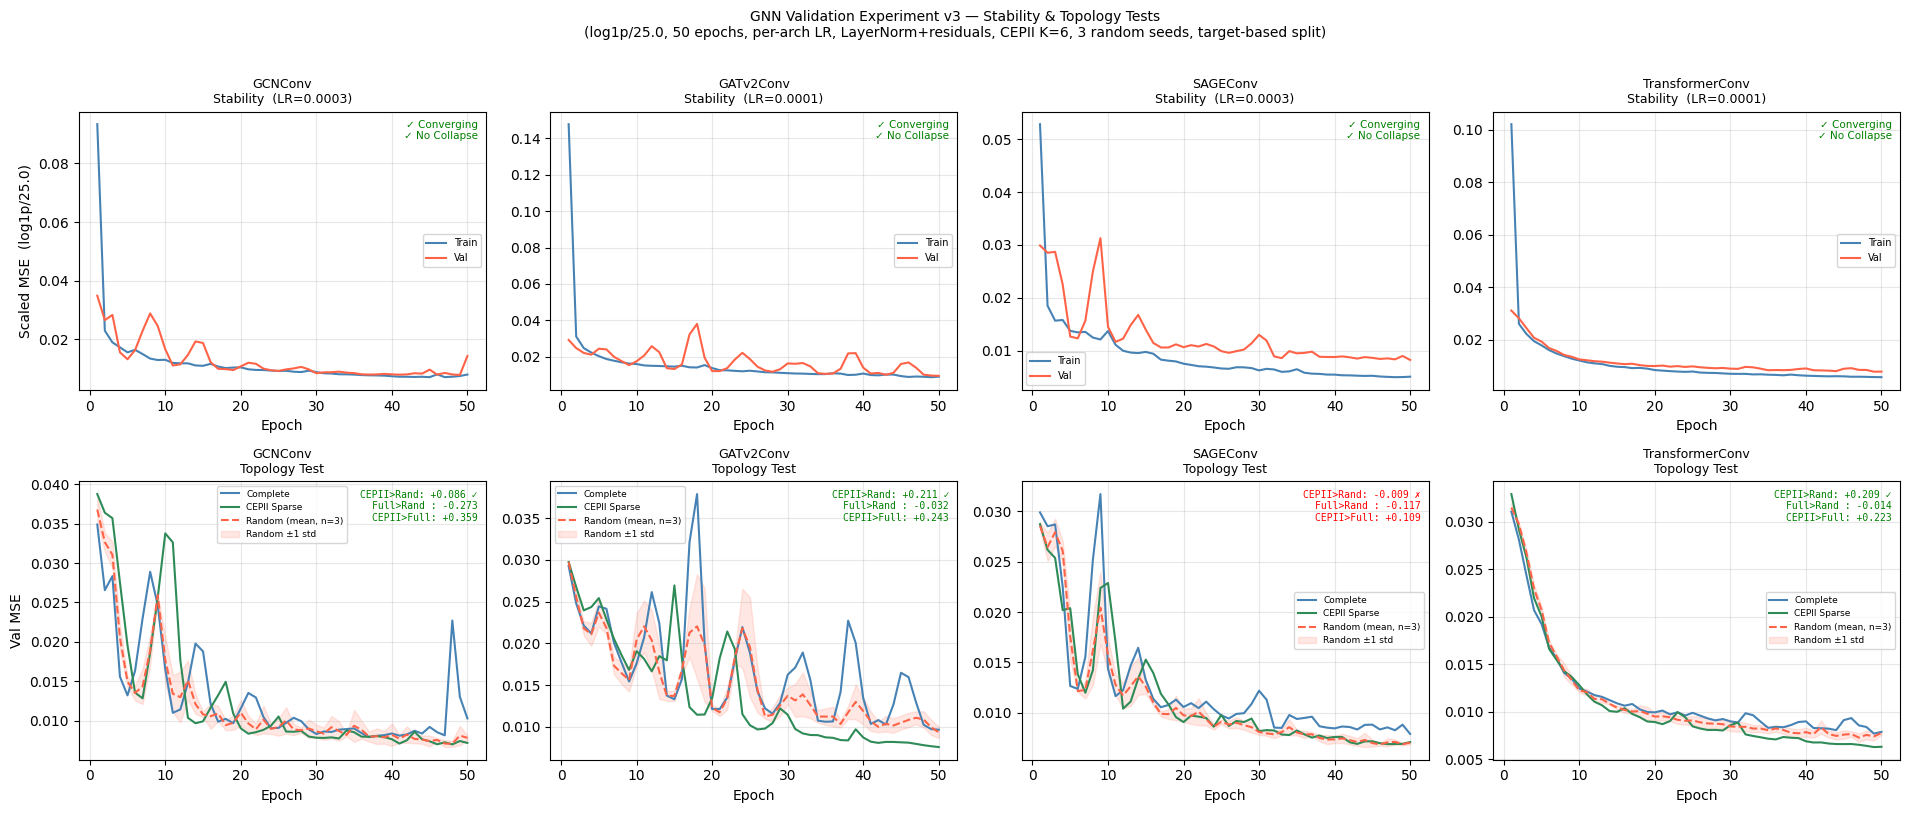

Saved: gnn_validation_v3.png


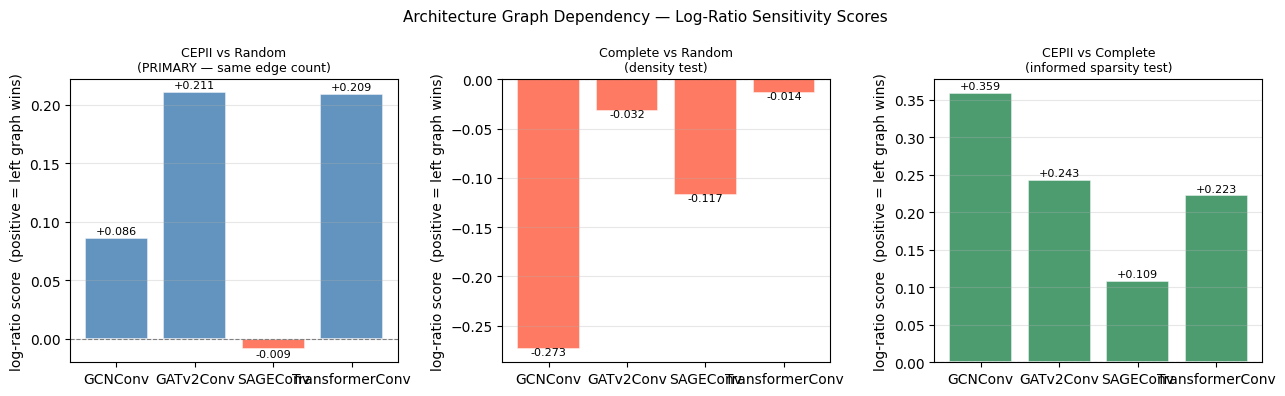

Saved: graph_sensitivity_v3.png


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell I — Results Table + Visualizations
# ══════════════════════════════════════════════════════════════════════════════

# ── I.1 Summary Table ─────────────────────────────────────────────────────────
print("\n" + "═" * 115)
print("  VALIDATION EXPERIMENT SUMMARY  (log-ratio scores: positive = left graph wins)")
print("═" * 115)
print(f"{'Architecture':<18}  {'LR':>6}  {'Stable':>6}  {'NoCollapse':>10}  "
      f"{'CompleteFinal':>13}  {'CEPIIFinal':>10}  {'RandMean±Std':>20}  "
      f"{'CEPII>Rand':>10}  {'Full>Rand':>9}  {'CEPII>Full':>10}")
print("─" * 115)

for name, r in sweep_results.items():
    rand_str = f"{r['rand_mean']:.5f} ± {r['rand_std']:.5f}"
    print(
        f"{name:<18}  "
        f"{r['arch_lr']:>6}  "
        f"{'✓' if r['stable'] else '✗':>6}  "
        f"{'✓' if r['not_collapsed'] else '✗':>10}  "
        f"{r['full_final']:>13.5f}  "
        f"{r['cepii_final']:>10.5f}  "
        f"{rand_str:>20}  "
        f"{r['score_cepii_vs_rand']:>+10.4f}  "
        f"{r['score_full_vs_rand']:>+9.4f}  "
        f"{r['score_cepii_vs_full']:>+10.4f}"
    )

print("═" * 115)
print("  CEPII>Rand: log(rand_mean / cepii_final)  — PRIMARY pure topology test (same edge count)")
print("  Full>Rand : log(rand_mean / full_final)   — does dense graph beat sparse random?")
print("  CEPII>Full: log(full_final / cepii_final) — does informed sparsity beat density?")


# ── I.2 Loss Curves ───────────────────────────────────────────────────────────
n_archs = len(sweep_results)
fig, axes = plt.subplots(2, n_archs, figsize=(4.8 * n_archs, 8), squeeze=False)

GRAPH_COLORS = {
    "Complete"    : ("steelblue",  "-"),
    "CEPII Sparse": ("seagreen",   "-"),
    "Random"      : ("tomato",     "--"),    # prefix match below
}

for col, (name, r) in enumerate(sweep_results.items()):
    epochs = range(1, len(r["val_losses"]) + 1)

    # ── Top: Stability ────────────────────────────────────────────────────────
    ax = axes[0, col]
    ax.plot(epochs, r["train_losses"], label="Train", color="steelblue", linewidth=1.5)
    ax.plot(epochs, r["val_losses"],   label="Val",   color="tomato",    linewidth=1.5)
    ax.set_title(f"{name}\nStability  (LR={r['arch_lr']})", fontsize=9)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(f"Scaled MSE  (log1p/{TARGET_SCALE})" if col == 0 else "")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    status = f"{'✓ Converging' if r['stable'] else '✗ Not Converging'}\n"\
             f"{'✓ No Collapse' if r['not_collapsed'] else '✗ Collapsed'}"
    ax.text(0.98, 0.97, status, transform=ax.transAxes,
            ha="right", va="top", fontsize=7.5,
            color="green" if (r["stable"] and r["not_collapsed"]) else "red")

    # ── Bottom: Topology (all 3 graph types) ──────────────────────────────────
    ax2   = axes[1, col]
    ep2   = range(1, N_EPOCHS + 1)
    hists = r["topo_hists"]

    ax2.plot(ep2, hists["Complete"],     label="Complete",     color="steelblue", linewidth=1.5, linestyle="-")
    ax2.plot(ep2, hists["CEPII Sparse"], label="CEPII Sparse", color="seagreen",  linewidth=1.5, linestyle="-")

    # Random sparse: mean ± std band across seeds
    rand_mat = np.array([hists[f"Random {s+1}"] for s in range(N_RAND_SEEDS)])
    rand_mu  = rand_mat.mean(axis=0)
    rand_sd  = rand_mat.std(axis=0)
    ax2.plot(ep2, rand_mu, label=f"Random (mean, n={N_RAND_SEEDS})",
             color="tomato", linewidth=1.5, linestyle="--")
    ax2.fill_between(ep2, rand_mu - rand_sd, rand_mu + rand_sd,
                     color="tomato", alpha=0.15, label="Random ±1 std")

    ax2.set_title(f"{name}\nTopology Test", fontsize=9)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Val MSE" if col == 0 else "")
    ax2.legend(fontsize=6.5)
    ax2.grid(True, alpha=0.3)

    cepii_wins = r["score_cepii_vs_rand"] > 0
    sens_txt   = (f"CEPII>Rand: {r['score_cepii_vs_rand']:+.3f} "
                  f"{'✓' if cepii_wins else '✗'}\n"
                  f"Full>Rand : {r['score_full_vs_rand']:+.3f}\n"
                  f"CEPII>Full: {r['score_cepii_vs_full']:+.3f}")
    ax2.text(0.98, 0.97, sens_txt, transform=ax2.transAxes,
             ha="right", va="top", fontsize=7,
             color="green" if cepii_wins else "red",
             fontfamily="monospace")

plt.suptitle(
    f"GNN Validation Experiment v3 — Stability & Topology Tests\n"
    f"(log1p/{TARGET_SCALE}, {N_EPOCHS} epochs, per-arch LR, LayerNorm+residuals, "
    f"CEPII K={K_NEIGHBORS}, {N_RAND_SEEDS} random seeds, target-based split)",
    fontsize=10, y=1.01,
)
plt.tight_layout()
plt.savefig("gnn_validation_v3.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: gnn_validation_v3.png")


# ── I.3 Three-panel sensitivity bar chart ─────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

comparisons = [
    ("CEPII vs Random\n(PRIMARY — same edge count)", "score_cepii_vs_rand",
     "steelblue", "tomato",   lambda r: r["score_cepii_vs_rand"] > 0),
    ("Complete vs Random\n(density test)",            "score_full_vs_rand",
     "mediumpurple", "tomato", lambda r: r["score_full_vs_rand"] > 0),
    ("CEPII vs Complete\n(informed sparsity test)",   "score_cepii_vs_full",
     "seagreen", "steelblue", lambda r: r["score_cepii_vs_full"] > 0),
]

names = list(sweep_results.keys())
for ax3, (title, key, win_col, lose_col, win_fn) in zip(axes2, comparisons):
    scores = [sweep_results[n][key] for n in names]
    colors = [win_col if win_fn(sweep_results[n]) else lose_col for n in names]
    bars   = ax3.bar(names, scores, color=colors, alpha=0.85, edgecolor="white", linewidth=1.2)
    ax3.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax3.set_title(title, fontsize=9)
    ax3.set_ylabel("log-ratio score  (positive = left graph wins)")
    ax3.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, scores):
        yoff = 0.002 if val >= 0 else -0.008
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + yoff,
                 f"{val:+.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Architecture Graph Dependency — Log-Ratio Sensitivity Scores", fontsize=11)
plt.tight_layout()
plt.savefig("graph_sensitivity_v3.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: graph_sensitivity_v3.png")
